<img src="https://s3.amazonaws.com/weclouddata/images/logos/wcd_logo_new_2.png" width="10%">

<h1><center>Example BERT output</center></h1>


## Import Labraries

In [1]:
# pip install transformers

In [2]:
import torch
import numpy as np

In [3]:
from pprint import pprint

In [4]:
device = "cpu"

In [5]:
from transformers import BertTokenizer, BertModel, AutoTokenizer

## Tokenizer

The Hugging Face Transformers library offers tokenizers that pair with their models.

Use tokenizer to convert text into token ids

https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.__call__

In [6]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased") # or BertTokenizer

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [7]:
inputs = tokenizer(
    "I arrived at the bank after acrossing the river",
    return_tensors="pt",     # stands for pytorch
    padding=True,
    truncation=True,
).to(device)

In [8]:
pprint(inputs)

{'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]),
 'input_ids': tensor([[ 101,  146, 2474, 1120, 1103, 3085, 1170, 1506, 1158, 1103, 2186,  102]]),
 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])}


In [9]:
pprint(inputs['input_ids'].shape)

torch.Size([1, 12])


In [10]:
# Check the output of BERT
texts = [
    "I arrived at the bank after acrossing the street.",
    "I arrived at the bank after acrossing the river.",
]

inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
pprint(inputs)

{'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]),
 'input_ids': tensor([[ 101,  146, 2474, 1120, 1103, 3085, 1170, 1506, 1158, 1103, 2472,  119,
          102],
        [ 101,  146, 2474, 1120, 1103, 3085, 1170, 1506, 1158, 1103, 2186,  119,
          102]]),
 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])}


We can use `tokenizer.decode()` with the ids to easily get the original text

In [11]:
for idx, token_id in enumerate(inputs["input_ids"][0]):
    print(idx, token_id, tokenizer.decode([token_id]))

0 tensor(101) [CLS]
1 tensor(146) I
2 tensor(2474) arrived
3 tensor(1120) at
4 tensor(1103) the
5 tensor(3085) bank
6 tensor(1170) after
7 tensor(1506) across
8 tensor(1158) ##ing
9 tensor(1103) the
10 tensor(2472) street
11 tensor(119) .
12 tensor(102) [SEP]


In [12]:
tokenizer.decode(inputs["input_ids"][0], skip_special_tokens=True)

'I arrived at the bank after acrossing the street.'

## Load the pre-trained model from the Hugging Face

In [13]:
model = BertModel.from_pretrained("bert-base-cased", output_attentions=True, attn_implementation='eager')

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
model = model.to(device)
model = model.eval()

In [15]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [16]:
# input2 = list(inputs.value())
input2 = list(inputs.keys())
input2

['input_ids', 'token_type_ids', 'attention_mask']

In [17]:
with torch.no_grad():
    outputs = model(**inputs.to(device))
    # **inputs here means unpack the dictionary
    # equivalent to passing each key-value pair as a keyword argument:
    # outputs = model(input_ids=inputs['input_ids'].to(device),
    #                 attention_mask=inputs['attention_mask'].to(device),
    #                 token_type_ids=inputs['token_type_ids'].to(device))

In [18]:
outputs

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[ 0.4819, -0.0522,  0.3908,  ..., -0.3521,  0.1465, -0.2201],
         [ 0.5318, -0.5215,  0.6203,  ..., -0.1984, -0.1061,  0.3180],
         [ 0.4444, -0.1669,  0.1895,  ...,  0.5116,  0.0126, -0.0693],
         ...,
         [ 0.5354, -0.2442,  0.5033,  ..., -0.2415,  0.1326, -0.0705],
         [ 0.2608, -0.4465,  0.1926,  ..., -0.2331, -0.0498, -0.3492],
         [ 1.0647, -0.6168,  0.3028,  ..., -0.0517,  0.5719,  0.0537]],

        [[ 0.4877, -0.0196,  0.2730,  ..., -0.4853,  0.1557, -0.1687],
         [ 0.4739, -0.5169,  0.5470,  ..., -0.2459, -0.1375,  0.4031],
         [ 0.3309, -0.3217,  0.0542,  ...,  0.2845,  0.1305,  0.0155],
         ...,
         [ 0.0605, -0.1376, -0.3122,  ..., -0.5301, -0.8172,  0.3758],
         [ 0.2435, -0.4100,  0.1249,  ..., -0.3043,  0.0063, -0.3218],
         [ 1.3980, -0.4451, -0.5251,  ..., -0.5287, -0.1863,  0.0685]]]), pooler_output=tensor([[-0.7995,  0.3037,  0.9997,  .

In [19]:
# Extract the embeddings for the word "bank" from the hidden states of the two sentences.
# Note: The index [5] is based on the token position of "bank" in the sentences. Ensure it's consistent with the tokenized output.
emb_bank_1 = outputs.last_hidden_state.detach().cpu().numpy()[0][5]
emb_bank_2 = outputs.last_hidden_state.detach().cpu().numpy()[1][5]

In [20]:
def cosine_similarity(a, b):
    a = a / np.sqrt((a**2).sum(-1))
    b = b / np.sqrt((b**2).sum(-1))
    return np.dot(a, b.T)

In [21]:
cosine_similarity(emb_bank_1, emb_bank_2)

np.float32(0.84096944)

Here we can see the BERT can generate the embedding base on it's context

## get attention weights

https://huggingface.co/docs/transformers/model_doc/bert#transformers.models.bert.modeling_bert.BertForPreTrainingOutput.attentions


In [22]:
with torch.no_grad():
    outputs = model(**inputs.to(device), output_attentions=True)

In [23]:
# get last layer's attention

# layer, batch_size, attention_head, sequence_length, sequence_length
outputs.attentions[-1].shape

torch.Size([2, 12, 13, 13])

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

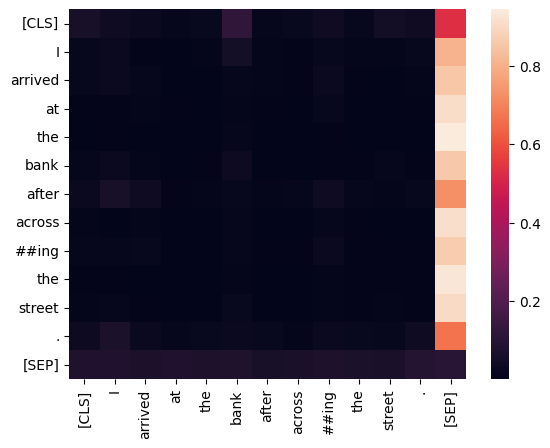

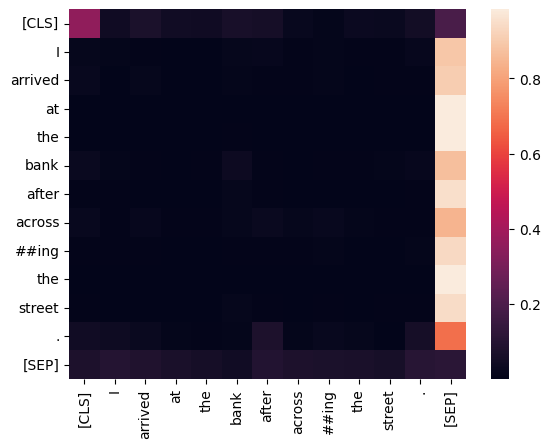

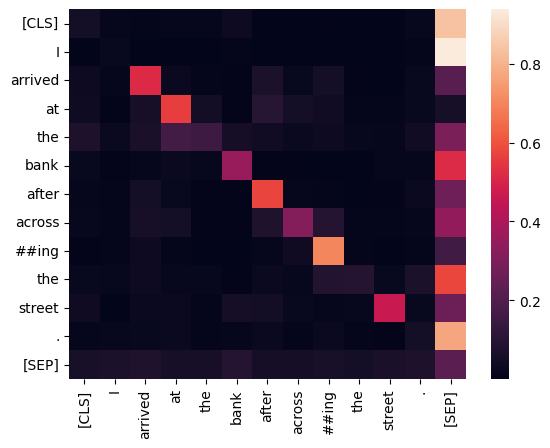

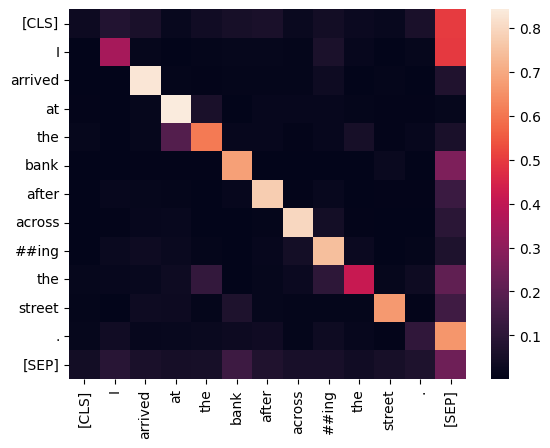

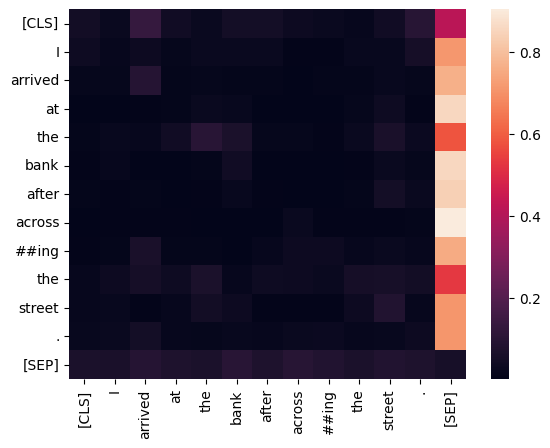

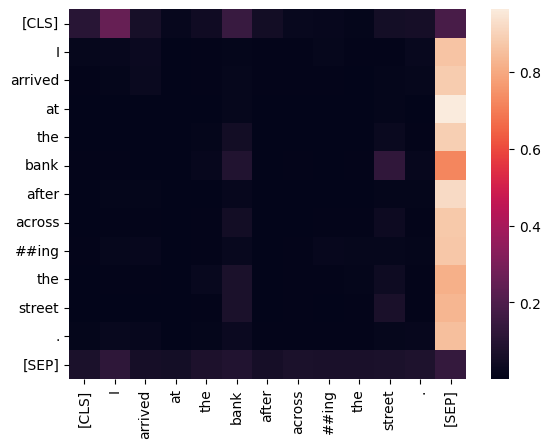

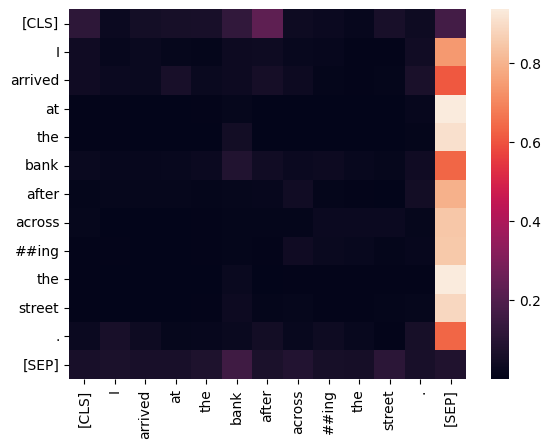

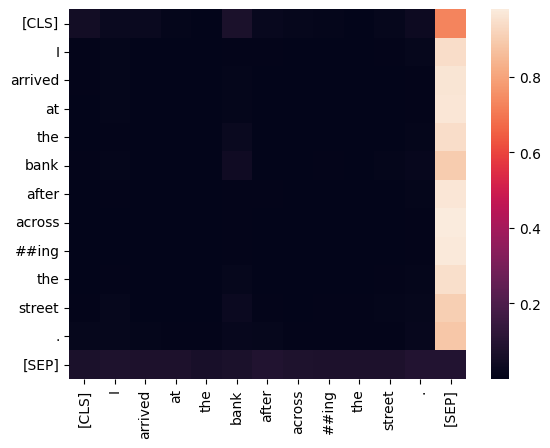

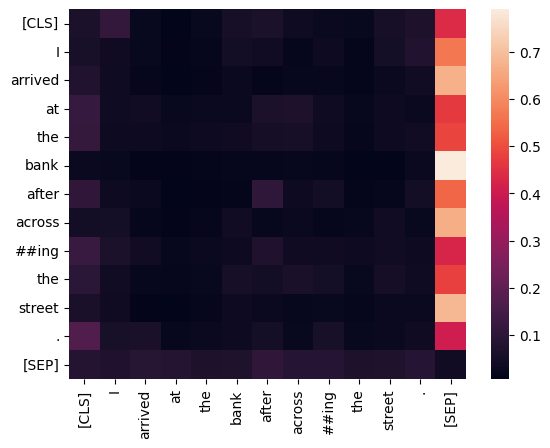

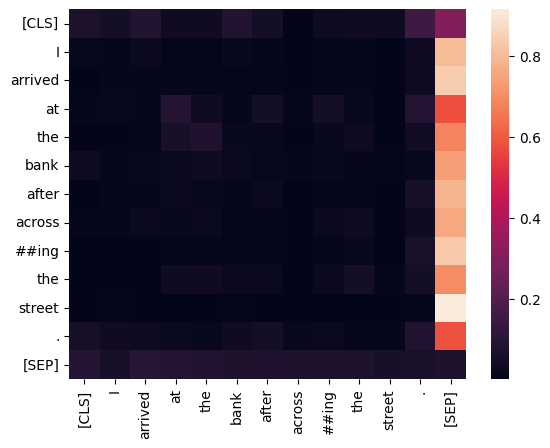

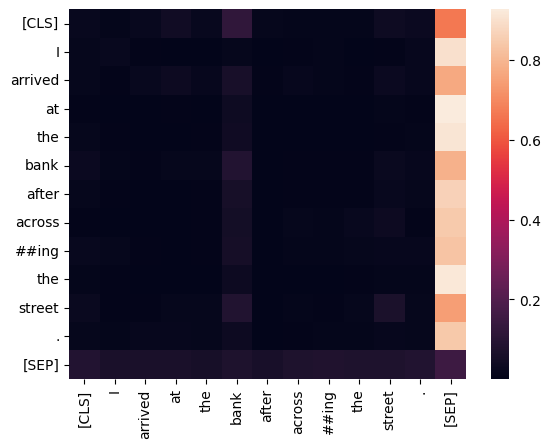

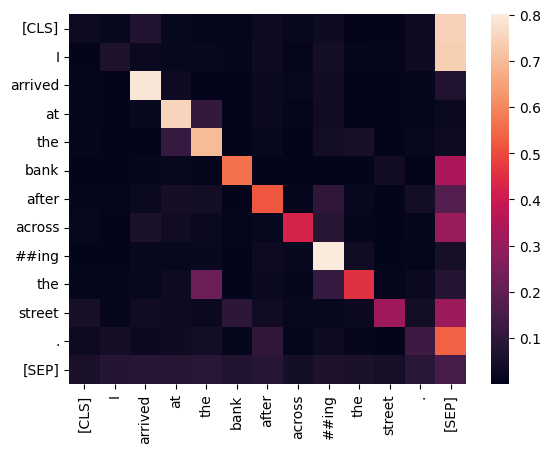

In [25]:
layer = -1
labels = [tokenizer.decode([token_id]) for token_id in inputs["input_ids"][0]]
for head_idx in range(12):
    plt.figure()
    sns.heatmap(
        outputs.attentions[layer][0][head_idx].detach().cpu().numpy(),
        xticklabels=labels,
        yticklabels=labels,
    )

In [26]:
import plotly.express as px

In [27]:
import plotly.io as pio
pio.renderers.default = "colab" # note if you want this to be displayed in
                                # jupyter notebook, change the renderer to
                                # "notebook" instead

In [28]:
fig = px.imshow(
    outputs.attentions[layer][0][head_idx].detach().cpu().numpy(),
    x=labels,
    y=labels,
)

fig.show()